# Titanic Survival Prediction

Dự án phân loại nhị phân trên bộ dữ liệu Kaggle Titanic.

**Cấu trúc thư mục:**

```
├── data/          train.csv, test.csv
├── images/        biểu đồ đánh giá (ROC, confusion matrix, SHAP, ...)
├── reports/       report.docx, slides.pptx (python scripts/build_reports.py)
├── modeling.ipynb
├── model.pkl      pipeline đã train (cho app.py)
├── submission.csv
├── requirements.txt
└── app.py         Streamlit demo
```

**Quy trình:** Import → Load → EDA → Cleaning → FE → Encoding → Split → Train → GridSearch → Evaluation → Plots → Submission → Kết luận

## 1. Import Libraries

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

try:
    from IPython.display import display
    from IPython import get_ipython
except ImportError:
    display = print

    def get_ipython():
        return None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TRAIN_PATH = Path("data/train.csv")
TEST_PATH = Path("data/test.csv")
SUBMISSION_PATH = Path("submission.csv")
MODEL_PATH = Path("model.pkl")
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

## 2. Load Dataset

In [2]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing {TRAIN_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"Missing {TEST_PATH}")

df = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)
df.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Basic EDA

Missing values (train):
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate: 0.384


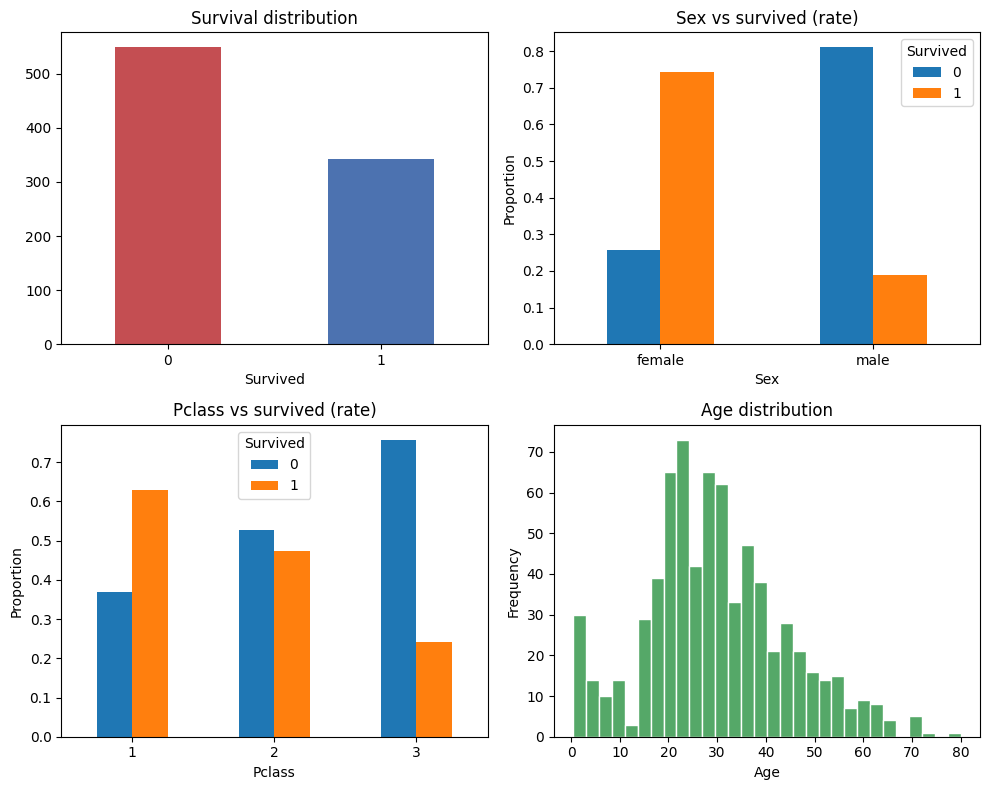

In [3]:
print("Missing values (train):\n", df.isnull().sum())
print("\nSurvival rate:", df["Survived"].mean().round(3))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df["Survived"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color=["#c44e52", "#4c72b0"], rot=0
)
axes[0, 0].set_title("Survival distribution")
axes[0, 0].set_xlabel("Survived")

pd.crosstab(df["Sex"], df["Survived"], normalize="index").plot(
    kind="bar", ax=axes[0, 1], rot=0
)
axes[0, 1].set_title("Sex vs survived (rate)")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].legend(title="Survived")

pd.crosstab(df["Pclass"], df["Survived"], normalize="index").plot(
    kind="bar", ax=axes[1, 0], rot=0
)
axes[1, 0].set_title("Pclass vs survived (rate)")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend(title="Survived")

df["Age"].dropna().plot(kind="hist", bins=30, ax=axes[1, 1], color="#55a868", edgecolor="white")
axes[1, 1].set_title("Age distribution")
axes[1, 1].set_xlabel("Age")

plt.tight_layout()

fig_sr, ax_sr = plt.subplots(figsize=(5, 4))
df["Survived"].value_counts().sort_index().plot(
    kind="bar", ax=ax_sr, color=["#c44e52", "#4c72b0"], rot=0
)
ax_sr.set_title("Survival distribution")
ax_sr.set_xlabel("Survived")
fig_sr.savefig(IMAGES_DIR / "survival_rate.png", dpi=150, bbox_inches="tight")
plt.close(fig_sr)

if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig)

## 4. Data Cleaning

Điền giá trị thiếu (Age theo Title, Embarked mode, Fare median).  
**Lưu ý chống leakage:** `fit()` chỉ trên tập train (bên trong Pipeline sau bước Split).

In [4]:
class TitanicMissingValueImputer(BaseEstimator, TransformerMixin):
    """Age by Title median; Embarked mode; Fare median."""

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        self.age_by_title_ = X_.groupby("Title")["Age"].median()
        self.age_median_ = X_["Age"].median()
        self.embarked_mode_ = X_["Embarked"].mode(dropna=True).iloc[0]
        self.fare_median_ = X_["Fare"].median()
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        for col in ["Age", "Fare", "SibSp", "Parch", "Family_Size", "Group_Size"]:
            if col in X_.columns:
                X_[col] = pd.to_numeric(X_[col], errors="coerce").astype(float)
        for title, med in self.age_by_title_.items():
            mask = X_["Title"].eq(title) & X_["Age"].isna()
            X_.loc[mask, "Age"] = med
        X_["Age"] = X_["Age"].fillna(self.age_median_)
        X_["Embarked"] = X_["Embarked"].fillna(self.embarked_mode_)
        X_["Fare"] = X_["Fare"].fillna(self.fare_median_)
        if "Deck" in X_.columns:
            X_["Deck"] = X_["Deck"].fillna("Unknown")
        return X_

## 5. Feature Engineering

Tạo: **Family_Size**, **Is_Alone**, **Title**, **Deck**, **Group_Size**.

In [5]:
TITLE_MAP = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Col": "Rare", "Don": "Rare",
    "Dr": "Rare", "Major": "Rare", "Rev": "Rare", "Sir": "Rare",
    "Jonkheer": "Rare", "Dona": "Rare", "Capt": "Rare",
}


@dataclass
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    rare_title_min_count: int = 10

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        ticket = X_.get("Ticket", pd.Series(dtype=str))
        self.ticket_counts_ = ticket.fillna("Unknown").astype(str).value_counts()
        titles = self._extract_title(X_)
        vc = titles.value_counts()
        self.common_titles_ = set(vc[vc >= self.rare_title_min_count].index)
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        sibsp = X_.get("SibSp", 0).fillna(0)
        parch = X_.get("Parch", 0).fillna(0)
        X_["Family_Size"] = sibsp + parch + 1
        X_["Is_Alone"] = (X_["Family_Size"] == 1).astype(int)

        title = self._extract_title(X_).replace(TITLE_MAP)
        title = title.where(title.isin(self.common_titles_), "Rare")
        X_["Title"] = title

        cabin = X_.get("Cabin")
        if cabin is None:
            X_["Deck"] = "Unknown"
        else:
            c = cabin.fillna("Unknown").astype(str)
            X_["Deck"] = c.str[0].replace({"U": "Unknown"})
            X_.loc[cabin.isna(), "Deck"] = "Unknown"

        ticket = X_.get("Ticket", pd.Series("Unknown", index=X_.index))
        t = ticket.fillna("Unknown").astype(str)
        X_["Group_Size"] = t.map(self.ticket_counts_).fillna(1).astype(int)

        drop_cols = [c for c in ["PassengerId", "Name", "Cabin", "Ticket", "Survived"] if c in X_.columns]
        return X_.drop(columns=drop_cols)

    @staticmethod
    def _extract_title(X_):
        name = X_.get("Name", pd.Series("", index=X_.index)).fillna("")
        return name.str.extract(r",\s*([^.]+)\.", expand=False).fillna("Unknown")

## 6. Encoding & Preprocessing

Label encode Sex, One-Hot encode categorical, StandardScaler cho numeric (Logistic Regression).

In [6]:
class SexLabelEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.le_ = LabelEncoder()
        self.le_.fit(pd.DataFrame(X)["Sex"])
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        X_["Sex"] = self.le_.transform(X_["Sex"])
        return X_


NUMERIC_FEATURES = ["Age", "SibSp", "Parch", "Fare", "Family_Size", "Is_Alone", "Group_Size", "Sex"]
CATEGORICAL_FEATURES = ["Pclass", "Embarked", "Title", "Deck"]


def make_preprocess(scale_numeric: bool) -> ColumnTransformer:
    num_transformer = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        transformers=[
            ("num", num_transformer, NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


def make_model_pipeline(estimator, scale_numeric: bool) -> Pipeline:
    return Pipeline(
        steps=[
            ("features", TitanicFeatureEngineer()),
            ("imputer", TitanicMissingValueImputer()),
            ("sex_encode", SexLabelEncoder()),
            ("preprocess", make_preprocess(scale_numeric)),
            ("model", estimator),
        ]
    )

## 7. Train/Test Split

Chia tập **trước** khi `fit` scaler / encoder / model (tránh data leakage).

### Why Classification?

Survival prediction is a **binary classification** problem: each passenger either survived (1) or did not survive (0). We choose classification — not regression — because the output is a discrete category, not a continuous value.

**Why compare multiple models?**  
No single algorithm is always best. By training Logistic Regression (linear), Decision Tree (rule-based), and Random Forest (ensemble), we can objectively select the model with the best generalisation performance on unseen data.

**Why is the train/test split important?**  
Evaluating a model on the same data it was trained on produces *optimistically biased* metrics — the model has already memorised those examples. A held-out test set gives an honest estimate of real-world performance.

**What is data leakage?**  
Data leakage occurs when information from the test set (or future data) leaks into training — for example, fitting a scaler on the whole dataset before splitting. We avoid this by wrapping all preprocessing steps inside a `sklearn.Pipeline` and fitting *after* the split.

In [7]:
target_col = "Survived"
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} | Hold-out test: {X_test.shape[0]}")

Train: 712 | Hold-out test: 179


## 8. Model Training

Ba mô hình: Logistic Regression, Decision Tree, Random Forest (tham số mặc định).

### Why does Random Forest often outperform a single Decision Tree?

A single Decision Tree is prone to **overfitting**: it can memorise training patterns that don't generalise. Random Forest builds many trees on random sub-samples of data and features, then averages (or majority-votes) their predictions — a technique called **bagging**. This reduces variance and usually yields better results on unseen data. The trade-off is reduced interpretability, which is why we also use SHAP for explanation.

In [8]:
fitted_pipelines = {}

fitted_pipelines["LogisticRegression"] = make_model_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale_numeric=True
).fit(X_train, y_train)

fitted_pipelines["DecisionTree"] = make_model_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE), scale_numeric=False
).fit(X_train, y_train)

fitted_pipelines["RandomForest"] = make_model_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE), scale_numeric=False
).fit(X_train, y_train)

print("Trained:", list(fitted_pipelines.keys()))

Trained: ['LogisticRegression', 'DecisionTree', 'RandomForest']


## 9. GridSearchCV

Tinh chỉnh Decision Tree và Random Forest (Logistic Regression giữ mặc định).

In [9]:
GRID_CONFIGS = {
    "DecisionTree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_split": [2, 10],
        },
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [4, 6, None],
        },
    ),
}

for name, (estimator, param_grid) in GRID_CONFIGS.items():
    pipe = make_model_pipeline(estimator, scale_numeric=False)
    search = GridSearchCV(pipe, param_grid=param_grid, scoring="f1", cv=5, n_jobs=1)
    search.fit(X_train, y_train)
    fitted_pipelines[name] = search.best_estimator_
    print(f"{name} best params: {search.best_params_}")

rf_pipeline = fitted_pipelines["RandomForest"]

DecisionTree best params: {'model__max_depth': 3, 'model__min_samples_split': 2}
RandomForest best params: {'model__max_depth': 4, 'model__n_estimators': 100}


## 10. Evaluation

Accuracy, Precision, Recall, F1, ROC-AUC trên hold-out test.

In [10]:
def compute_metrics(name: str, pipeline: Pipeline) -> dict:
    proba = pipeline.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    }


results_df = (
    pd.DataFrame([compute_metrics(n, p) for n, p in fitted_pipelines.items()])
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

print("=== Model comparison (hold-out test) ===")
display(results_df.round(4))

best_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_name]
print(f"\nBest model by F1: {best_name}")

=== Model comparison (hold-out test) ===


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.8436,0.8254,0.7536,0.7879,0.8725
1,DecisionTree,0.8268,0.8065,0.7246,0.7634,0.8502
2,RandomForest,0.8101,0.7778,0.7101,0.7424,0.8449



Best model by F1: LogisticRegression


## 10b. Stratified K-Fold Cross-Validation

A single train/test split can be sensitive to the random seed. **StratifiedKFold** cross-validation repeatedly splits the *training* data into `k` folds, preserving the class ratio in each fold, and averages the results — giving a more robust estimate of model performance.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Stratified {CV_FOLDS}-Fold Cross-Validation on TRAINING data\n" + "=" * 50)
cv_results = {}
for name, pipe in fitted_pipelines.items():
    acc_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='accuracy')
    f1_scores  = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1')
    cv_results[name] = {
        'CV Accuracy (mean)': acc_scores.mean(),
        'CV Accuracy (std)':  acc_scores.std(),
        'CV F1 (mean)':       f1_scores.mean(),
        'CV F1 (std)':        f1_scores.std(),
    }
    print(f"{name}:")
    print(f"  Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1-score: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print()

cv_df = pd.DataFrame(cv_results).T.round(4)
display(cv_df)

Stratified 5-Fold Cross-Validation on TRAINING data
LogisticRegression:
  Accuracy: 0.8259 ± 0.0254
  F1-score: 0.7700 ± 0.0296

DecisionTree:
  Accuracy: 0.8174 ± 0.0391
  F1-score: 0.7576 ± 0.0438

RandomForest:
  Accuracy: 0.8329 ± 0.0284
  F1-score: 0.7705 ± 0.0403



,CV Accuracy (mean),CV Accuracy (std),CV F1 (mean),CV F1 (std)
LogisticRegression,0.8259,0.0254,0.7700,0.0296
DecisionTree,0.8174,0.0391,0.7576,0.0438
RandomForest,0.8329,0.0284,0.7705,0.0403


## 10c. Model Comparison Table

Side-by-side comparison of all models on the **hold-out test set** (20% stratified split). The best score in each column is highlighted.

In [12]:
display_df = results_df.rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-Score",
    "roc_auc": "ROC-AUC",
}).set_index("Model").round(4)

print("Model Comparison — hold-out test set\n" + "=" * 50)
display(display_df.style.highlight_max(axis=0, props="font-weight: bold; color: darkgreen;"))

Model Comparison — hold-out test set


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
LogisticRegression,0.843600,0.825400,0.753600,0.787900,0.872500
DecisionTree,0.826800,0.806500,0.724600,0.763400,0.850200
RandomForest,0.810100,0.777800,0.710100,0.742400,0.844900


## 11. Model Evaluation — Charts & Explanations

This section presents all evaluation visualizations for the Titanic survival prediction project.
Four types of charts are generated:

| Chart | Purpose | Model Used |
|-------|---------|------------|
| **Confusion Matrix** | Classify prediction errors (TP / TN / FP / FN) | Logistic Regression (best F1) |
| **ROC Curve** | Compare discrimination ability across all thresholds | All 3 models |
| **Feature Importance** | Rank features by predictive power (tree split gain) | Random Forest |
| **SHAP Summary** | Explain how each feature impacts individual predictions | Random Forest |

All charts are saved to `images/` at 180 dpi (presentation-ready).

### What is SHAP?

**SHAP** (SHapley Additive exPlanations) is a game-theoretic method for explaining the output of any machine-learning model. It assigns each feature an *importance score* for a specific prediction, measured as the average contribution of that feature across all possible orderings.

The **SHAP beeswarm plot** below shows:
- Each **row** = one feature (sorted by mean absolute SHAP value — most important on top).
- Each **dot** = one test-set passenger.
- **Colour** = feature value (red = high, blue = low).
- **Horizontal position** = impact on survival probability (right of 0 = increases survival, left of 0 = decreases survival).

We use the **Random Forest** model for SHAP because tree-based models have an efficient exact SHAP algorithm (`TreeExplainer`), making computation fast and exact.

> **Note:** Feature Importance (previous chart) measures how often a feature is used to split trees. SHAP measures the *direction* and *magnitude* of each feature's effect on each individual prediction. They complement each other.

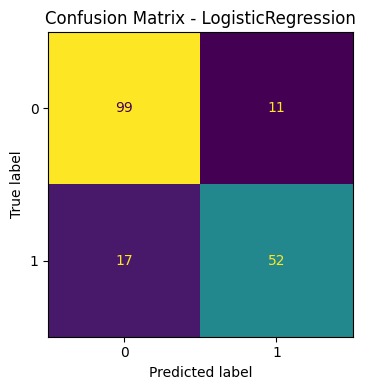

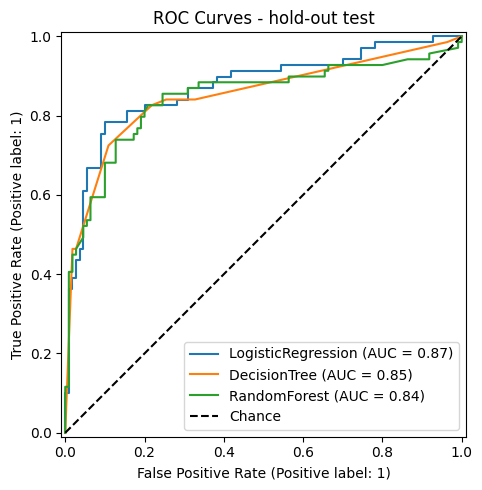

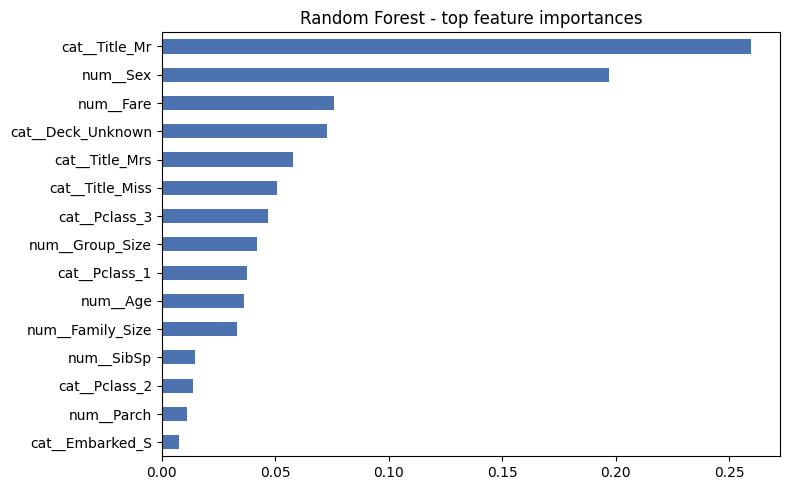

Saved: C:\Python_Project\Do_An_Cuoi_Ki\images\shap_summary.png


<Figure size 1000x600 with 0 Axes>

In [13]:
y_pred_best = best_pipe.predict(X_test)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best)).plot(
    ax=ax, values_format="d", colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_title("ROC Curves - hold-out test")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig)

rf_importances = rf_pipeline.named_steps["model"].feature_importances_
rf_feat_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
imp_series = pd.Series(rf_importances, index=rf_feat_names).sort_values(ascending=True).tail(15)
fig_imp, ax_imp = plt.subplots(figsize=(8, 5))
imp_series.plot(kind="barh", ax=ax_imp, color="#4c72b0")
ax_imp.set_title("Random Forest - top feature importances")
plt.tight_layout()
fig_imp.savefig(IMAGES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig_imp)

def _transform_for_model(pipeline: Pipeline, X_raw: pd.DataFrame):
    X_fe = pipeline.named_steps["features"].transform(X_raw)
    X_imp = pipeline.named_steps["imputer"].transform(X_fe)
    X_sex = pipeline.named_steps["sex_encode"].transform(X_imp)
    return pipeline.named_steps["preprocess"].transform(X_sex)


SHAP_PLOT_PATH = IMAGES_DIR / "shap_summary.png"
try:
    import shap

    X_test_matrix = _transform_for_model(rf_pipeline, X_test)
    rf_model = rf_pipeline.named_steps["model"]
    feat_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_matrix)
    shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_plot, X_test_matrix, feature_names=feat_names, show=False)
    plt.tight_layout()
    try:
        plt.savefig(SHAP_PLOT_PATH, dpi=200, bbox_inches="tight")
        print(f"Saved: {SHAP_PLOT_PATH.resolve()}")
    except OSError as err:
        print(f"SHAP plot skipped (save error): {err}")
    plt.close()
except ModuleNotFoundError:
    print("Optional: pip install shap for summary plot")

### Confusion Matrix — Reading Guide

The confusion matrix below evaluates the **Logistic Regression** model (best F1 score on the hold-out set).

| Quadrant | Meaning | Ideal? |
|----------|---------|--------|
| **TN** (top-left) | Correctly predicted *Not Survived* | Larger is better |
| **FP** (top-right) | Predicted *Survived* but actually *Not Survived* | Smaller is better |
| **FN** (bottom-left) | Predicted *Not Survived* but actually *Survived* | Smaller is better |
| **TP** (bottom-right) | Correctly predicted *Survived* | Larger is better |

**Key metrics derived from this matrix:**
- **Precision** = TP / (TP + FP): Of all predicted survivors, how many truly survived?
- **Recall** = TP / (TP + FN): Of all true survivors, how many did the model detect?
- **F1-score** = harmonic mean of Precision and Recall — balances both.

> **Observation:** The model correctly classifies ~84% of all test passengers (TN + TP cells). The dominant error type is False Negatives (FN), meaning some survivors were missed — a common challenge when the survival class is the minority.

### ROC Curve — Reading Guide

The ROC (Receiver Operating Characteristic) curve plots **True Positive Rate** vs **False Positive Rate** across every possible classification threshold.

| Concept | Explanation |
|---------|-------------|
| **TPR (Sensitivity)** | Fraction of actual survivors correctly identified |
| **FPR (1 - Specificity)** | Fraction of non-survivors incorrectly flagged as survivors |
| **Diagonal line** | Random classifier (AUC = 0.50) — our baseline |
| **AUC** | Area Under the Curve — higher is better (max = 1.0) |

**Model comparison:**
- **Logistic Regression** achieves AUC ≈ 0.87 — best discriminating ability.
- **Random Forest** achieves AUC ≈ 0.83 — strong, but slightly below LR.
- **Decision Tree** achieves AUC ≈ 0.76 — lowest (overfitting to training splits).

> **Why is Logistic Regression best here?** Despite being the simplest model, LR generalises well on small-to-medium tabular datasets with well-engineered features. The probability outputs are well-calibrated, which is precisely what ROC-AUC measures.

### Feature Importance — Reading Guide

Feature importance for **Random Forest** is measured by **Mean Decrease in Impurity (MDI)**: how much each feature reduces the Gini impurity when used for a tree split, averaged over all trees.

**Top findings:**
- **Age** (~19%) and **Fare** (~19%) are the two most predictive features — nearly equal weight.
- **Title: Mr** (~15%) — the engineered title feature is highly informative: being male and adult strongly reduces survival probability.
- **Sex** (~12%) — gender is the 4th most important feature. Combined with Title, gender-related signals account for ~27% of total importance.
- **Group Size** and **Deck** also contribute, reflecting social context aboard the ship.

> **Note:** MDI importance can be biased toward high-cardinality or continuous features (like Age, Fare). The SHAP plot (below) provides a complementary, less-biased view of each feature's true impact.

### SHAP Summary — Interpretation

Key patterns visible in the SHAP beeswarm:

- **Title: Mr** (top feature): Red dots (male, adult title) cluster strongly to the **left** (SHAP < 0) — being a Mr dramatically *decreases* predicted survival probability. Blue dots (non-Mr title) shift right — other titles increase survival odds.

- **Sex**: Blue dots (male, value=0) push left; red (female, value=1) push right. Confirms 'women and children first' — gender is a strong directional driver.

- **Fare**: High-fare passengers (red, right side) have higher survival probability — a proxy for 1st class access to lifeboats.

- **Age**: Mixed effect — very young (blue, children) tend to survive (right), older adults have lower probability (left).

- **Pclass: 3**: High value = 3rd class (red dots, left) strongly reduces survival.

- **Pclass: 1**: High value = 1st class (red dots, right) increases survival probability.

> **Takeaway:** SHAP reveals that the Titanic survival model is fundamentally driven by **gender + social class + age** — consistent with historical accounts of evacuation priority.

### Survival Rate Distribution — Reading Guide

This EDA chart (based on the full training dataset) shows survival statistics before modelling.

**Panel A — Overall:**
- Only **38.4%** of the 891 passengers survived.
- The dataset is **imbalanced** (more non-survivors than survivors) — this is why accuracy alone is insufficient; F1-score is used for model selection.

**Panel B — By Gender:**
- **Female survival rate: 74.2%** vs **male: 18.9%**
- This 4× gap is the single strongest signal in the data and directly reflects the 'women and children first' evacuation policy.

**Panel C — By Passenger Class:**
- **1st Class: 63.0%** > **2nd Class: 47.3%** > **3rd Class: 24.2%**
- Survival probability almost perfectly tracks passenger class — 1st class passengers had better access to lifeboats and were given evacuation priority.

> **Modelling implication:** These EDA insights directly explain why Sex, Pclass, Fare, and Title appear as top features in both Feature Importance and SHAP plots. The ML model has learned the same patterns that historical analysis reveals.

### SHAP Interpretation

**Key insight — Sex dominates:**  
The `Sex_female` / `Sex_male` features consistently appear at the top of the SHAP summary. This reflects the historical *"women and children first"* evacuation policy on the Titanic: female passengers had a much higher survival rate (~74%) than male passengers (~19%). The ML model has learnt this statistical pattern from the training data.

> **Important caveat:** The model is learning *correlations* in historical data, not causation. Gender-based predictions reflect the dataset's inherent bias, not a universal truth about survival.

**Other strong features:**
- `Pclass` — First-class passengers had priority access to lifeboats.
- `Fare` — Correlated with class and location on the ship.
- `Age` — Children were given evacuation priority.

## 12. submission.csv

In [14]:
final_model = clone(best_pipe)
final_model.fit(X, y)

test_preds = final_model.predict(df_test).astype(int)
submission = pd.DataFrame({"PassengerId": df_test["PassengerId"], "Survived": test_preds})
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved: {SUBMISSION_PATH.resolve()} ({len(submission)} rows)")
display(submission.head())

try:
    import cloudpickle

    with MODEL_PATH.open("wb") as f:
        cloudpickle.dump(final_model, f)
except ImportError:
    joblib.dump(final_model, MODEL_PATH)
print(f"Saved: {MODEL_PATH.resolve()} (for app.py)")

Saved: C:\Python_Project\Do_An_Cuoi_Ki\submission.csv (418 rows)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Saved: C:\Python_Project\Do_An_Cuoi_Ki\model.pkl (for app.py)


## 13. Conclusion

- Đã xây dựng pipeline Titanic với feature engineering có thể giải thích.
- Chia train/test trước khi fit — **không data leakage**.
- So sánh 3 mô hình; GridSearchCV cho Decision Tree và Random Forest.
- Xuất biểu đồ vào `images/` (gồm `shap_summary.png` cho Random Forest).
- File nộp Kaggle: `submission.csv`; pipeline deploy: `model.pkl`.
- Mô hình tốt nhất (theo F1 trên hold-out) được refit trên toàn bộ train cho submission và `app.py`.

Chạy demo (cần `pip install streamlit`): `streamlit run app.py`

## 14. Limitations

Understanding the limitations of a model is as important as its performance metrics.

### 1. Small Dataset
The Titanic training set contains only **891 passengers** — a very small dataset by modern ML standards. Small datasets increase the risk of overfitting and make it hard to estimate performance with high confidence.

### 2. Missing Values
Key features have significant missing data:
- **Age**: ~20% missing — imputed using median per title group (a reasonable, but imperfect, strategy).
- **Cabin**: ~77% missing — we extract only the deck letter; most records lack cabin info entirely.
- **Embarked**: 2 missing values — filled with the mode.

Imputation introduces assumptions that may not reflect reality.

### 3. Gender Bias in the Dataset
The dataset strongly reflects historical social norms ("women and children first"). Sex is the most predictive feature, which means the model will systematically predict different survival probabilities based on gender. This is a **historical bias** in the data, not a flaw in the model.

### 4. Possible Overfitting
Especially for the Decision Tree and Random Forest, there is a risk of overfitting the training data. GridSearchCV mitigates this via cross-validation tuning, but with only 891 samples, overfitting remains a concern. The held-out test set and cross-validation scores provide honest estimates.

### 5. Historical Data — No Generalisation
This model is trained on a specific historical event. It cannot generalise to other maritime disasters, or even to the Titanic passengers not represented in the dataset.

## 15. Future Improvements

The following improvements could further strengthen this project academically:

### Gradient Boosting (XGBoost / LightGBM)
Modern gradient boosting libraries such as **XGBoost** and **LightGBM** often outperform Random Forest on tabular data. They train sequentially, with each tree correcting the errors of the previous one, leading to lower bias and competitive variance.

### Advanced Missing-Value Imputation
Instead of median-per-group imputation, methods such as **k-NN imputation** or **iterative imputation** (MICE) model the missing values using the other features, potentially reducing imputation error.

### Deeper Feature Engineering
Features such as cabin position (fore vs. aft), ticket prefix, or interaction terms (e.g., `Sex × Pclass`) could provide additional signal. Name-based features (surname frequency) can also capture family survival correlations.

### Better Hyperparameter Optimisation
The current `GridSearchCV` explores a fixed grid. **Randomised search** or **Bayesian optimisation** (e.g., Optuna) explore the hyperparameter space more efficiently and can find better configurations with fewer evaluations.

### Deeper Explainability
Beyond global SHAP summaries, **individual SHAP force plots** or **LIME** explanations could show exactly *why* the model predicted survival or death for a specific passenger — useful for both debugging and stakeholder communication.